In [ ]:
!pip -q install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.0 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **MODEL IMPORT**

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/thermal_data/yolov8_gas_classifier.pt")
metrics = model.val()

print("Top-1 Accuracy:", metrics.top1)
print("Top-5 Accuracy:", metrics.top5)
print("Fitness:", metrics.fitness)
print("Speed:", metrics.speed)

Ultralytics 8.4.25 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-cls summary (fused): 30 layers, 1,440,004 parameters, 0 gradients, 3.3 GFLOPs
train: /content/drive/MyDrive/thermal_data/Thermal_Camera/train... found 5120 images in 4 classes ✅ 
val: /content/drive/MyDrive/thermal_data/Thermal_Camera/val... found 1280 images in 4 classes ✅ 
test: None...
val: Fast image access ✅ (ping: 2.4±2.6 ms, read: 63.2±39.1 MB/s, size: 466.5 KB)
val: Scanning /content/drive/MyDrive/thermal_data/Thermal_Camera/val... 1280 images, 0 corrupt: 100% ━━━━━━━━━━━━ 1280/1280 214.7Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 80/80 2.3it/s 35.4s
                   all      0.988          1
Speed: 0.1ms preprocess, 0.8ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val3
Top-1 Accuracy: 0.98828125
Top-5 Accuracy: 1.0
Fitness: 0.994140625
Speed: {'preprocess': 0.07621451093662301, 'inference': 0.780714169530227

# **RESULTS AND ANALYSIS**

In [ ]:
import pandas as pd

yolo_summary_df = pd.DataFrame([
    {
        "Metric": "Top-1 Accuracy",
        "Value": float(metrics.top1)
    },
    {
        "Metric": "Top-5 Accuracy",
        "Value": float(metrics.top5)
    },
    {
        "Metric": "Fitness",
        "Value": float(metrics.fitness)
    },
    {
        "Metric": "Preprocess (ms)",
        "Value": float(metrics.speed["preprocess"])
    },
    {
        "Metric": "Inference (ms)",
        "Value": float(metrics.speed["inference"])
    },
    {
        "Metric": "Loss (ms)",
        "Value": float(metrics.speed["loss"])
    },
    {
        "Metric": "Postprocess (ms)",
        "Value": float(metrics.speed["postprocess"])
    },
])

print(yolo_summary_df)

             Metric     Value
0    Top-1 Accuracy  0.988281
1    Top-5 Accuracy  1.000000
2           Fitness  0.994141
3   Preprocess (ms)  0.074854
4    Inference (ms)  0.453096
5         Loss (ms)  0.000553
6  Postprocess (ms)  0.000852


In [ ]:
import os
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

val_dir = "/content/drive/MyDrive/thermal_data/Thermal_Camera/val"

class_names = sorted([
    d for d in os.listdir(val_dir)
    if os.path.isdir(os.path.join(val_dir, d))
])

y_true = []
y_pred = []
file_records = []

for true_idx, class_name in enumerate(class_names):
    class_path = os.path.join(val_dir, class_name)

    for fname in os.listdir(class_path):
        fpath = os.path.join(class_path, fname)

        result = model(fpath, verbose=False)[0]
        pred_idx = int(result.probs.top1)
        pred_conf = float(result.probs.top1conf)

        y_true.append(true_idx)
        y_pred.append(pred_idx)

        file_records.append({
            "file_name": fname,
            "true_class": class_name,
            "pred_class": class_names[pred_idx],
            "confidence": pred_conf,
            "correct": class_name == class_names[pred_idx]
        })

predictions_df = pd.DataFrame(file_records)
print(predictions_df.head())

          file_name true_class pred_class  confidence  correct
0  1263_Mixture.png    Mixture    Mixture         1.0     True
1  1257_Mixture.png    Mixture    Mixture         1.0     True
2  1433_Mixture.png    Mixture    Mixture         1.0     True
3   693_Mixture.png    Mixture    Mixture         1.0     True
4   679_Mixture.png    Mixture    Mixture         1.0     True


In [ ]:
cm = confusion_matrix(y_true, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=[f"True_{c}" for c in class_names],
    columns=[f"Pred_{c}" for c in class_names]
)

print(cm_df)

              Pred_Mixture  Pred_NoGas  Pred_Perfume  Pred_Smoke
True_Mixture           320           0             0           0
True_NoGas               0         308             9           3
True_Perfume             0           3           317           0
True_Smoke               0           0             0         320


In [ ]:
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
    digits=4
)

report_df = pd.DataFrame(report_dict).transpose()
print(report_df)

              precision    recall  f1-score      support
Mixture        1.000000  1.000000  1.000000   320.000000
NoGas          0.990354  0.962500  0.976228   320.000000
Perfume        0.972393  0.990625  0.981424   320.000000
Smoke          0.990712  1.000000  0.995334   320.000000
accuracy       0.988281  0.988281  0.988281     0.988281
macro avg      0.988365  0.988281  0.988247  1280.000000
weighted avg   0.988365  0.988281  0.988247  1280.000000


In [ ]:
per_class_accuracy = []

for i, class_name in enumerate(class_names):
    class_mask = np.array(y_true) == i
    acc = (np.array(y_pred)[class_mask] == i).mean()
    per_class_accuracy.append({
        "class_name": class_name,
        "class_accuracy": acc,
        "support": int(class_mask.sum())
    })

per_class_acc_df = pd.DataFrame(per_class_accuracy)
print(per_class_acc_df)

  class_name  class_accuracy  support
0    Mixture        1.000000      320
1      NoGas        0.962500      320
2    Perfume        0.990625      320
3      Smoke        1.000000      320


In [ ]:
misclassified_df = predictions_df[predictions_df["correct"] == False].copy()
misclassified_df = misclassified_df.sort_values("confidence", ascending=False)

print(misclassified_df.head(20))

            file_name true_class pred_class  confidence  correct
604     281_NoGas.png      NoGas    Perfume    0.999923    False
384     283_NoGas.png      NoGas    Perfume    0.999825    False
884    42_Perfume.png    Perfume      NoGas    0.992440    False
571     287_NoGas.png      NoGas    Perfume    0.991406    False
487     280_NoGas.png      NoGas    Perfume    0.991405    False
856    41_Perfume.png    Perfume      NoGas    0.980923    False
663  1124_Perfume.png    Perfume      NoGas    0.880750    False
562     654_NoGas.png      NoGas    Perfume    0.873264    False
615     303_NoGas.png      NoGas    Perfume    0.845218    False
450     461_NoGas.png      NoGas      Smoke    0.705503    False
442     330_NoGas.png      NoGas    Perfume    0.698180    False
620     262_NoGas.png      NoGas    Perfume    0.638871    False
557      80_NoGas.png      NoGas      Smoke    0.577024    False
500     459_NoGas.png      NoGas      Smoke    0.537722    False
404     323_NoGas.png    

# **VISUALIZATIONS AND PLOTS**

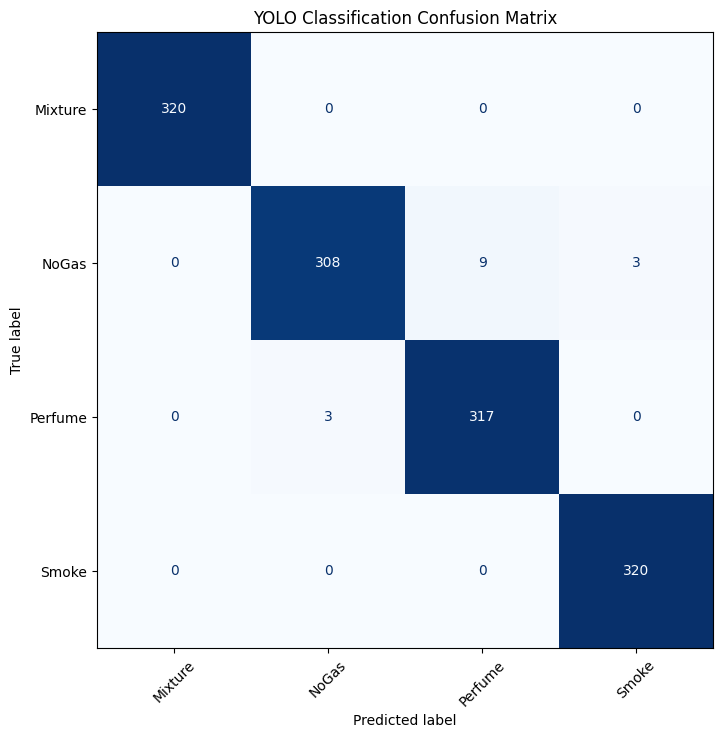

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
plt.title("YOLO Classification Confusion Matrix")
plt.show()

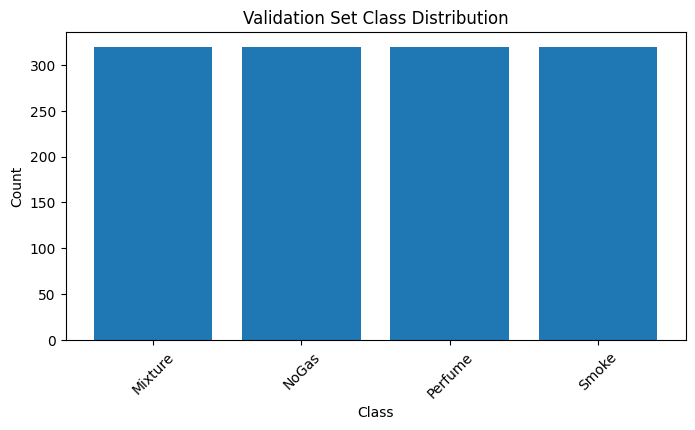

In [ ]:
val_distribution_df = predictions_df.groupby("true_class").size().reset_index(name="count")

plt.figure(figsize=(8, 4))
plt.bar(val_distribution_df["true_class"], val_distribution_df["count"])
plt.xticks(rotation=45)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Validation Set Class Distribution")
plt.show()

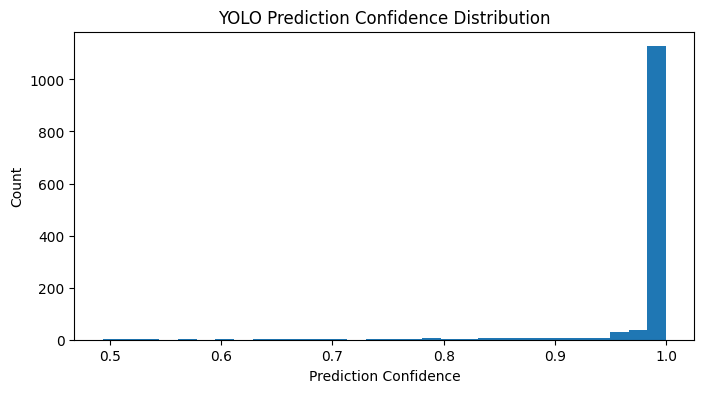

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(predictions_df["confidence"], bins=30)
plt.xlabel("Prediction Confidence")
plt.ylabel("Count")
plt.title("YOLO Prediction Confidence Distribution")
plt.show()